In [228]:
import itertools
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import pack

In [245]:
# Parameters for data generation
n_orders = 100000  # Total number of orders to generate

# Skewed distribution for number of items per order:
# 1 item - less often, 2 and 3 items - most common, 4 items - slightly less common
n_items_per_order = np.random.choice([1, 2, 3, 4], size=n_orders, p=[0.1, 0.4, 0.4, 0.1])

# Lists to store generated data
order_ids = []
item_ids = []
category_ids = []
quantities = []
dates = []

# Define the possible range of item_ids and category_ids
possible_item_ids = np.arange(100, 2000)  # Range of item_ids (2000 unique items)
possible_category_ids = np.arange(1, 150)  # 150 unique categories

# Start date for the generated dataset
start_date = pd.Timestamp('2025-01-01')

# Generate a unique date for each order_id (spread over ~6 months)
order_dates = start_date + pd.to_timedelta(np.random.randint(0, 180, size=n_orders), unit='d')

# Generate the data for orders
for order_id in range(1, n_orders + 1):
    # Number of items in this order (from the skewed distribution)
    n_items = n_items_per_order[order_id - 1]
    
    # Randomly select item_ids for the order (items can repeat in different orders)
    item_ids_in_order = np.random.choice(possible_item_ids, size=n_items, replace=True)
    
    # Randomly select categories for these items
    category_ids_in_order = np.random.choice(possible_category_ids, size=n_items, replace=True)
    
    # Assign the pre-generated date for this order_id
    date_for_order = order_dates[order_id - 1]
    
    # Loop through each item in this order and store the details
    for item_id, category_id in zip(item_ids_in_order, category_ids_in_order):
        order_ids.append(order_id)
        item_ids.append(item_id)
        category_ids.append(category_id)
        quantities.append(np.random.randint(1, 5))  # Random quantity between 1 and 4
        dates.append(date_for_order)  # Same date for all items in this order

# Create a DataFrame from the generated lists
df = pd.DataFrame({
    'order_id': order_ids,
    'item_id': item_ids,
    'category_id': category_ids,
    'quantity': quantities,
    'dt': dates
})

# Convert the 'dt' column to datetime format and keep only the date (drop time part)
df['dt'] = pd.to_datetime(df['dt']).dt.date


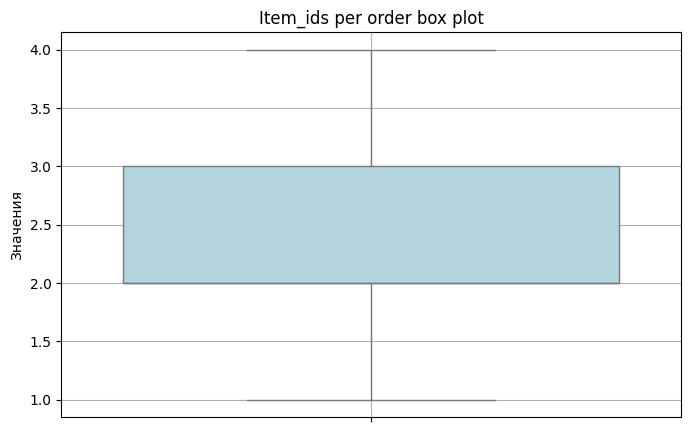

In [142]:
#the median items count per order
pack.plot_box(df.groupby('order_id').agg({'item_id': 'count'}).reset_index()['item_id'], title='Item_ids per order box plot')

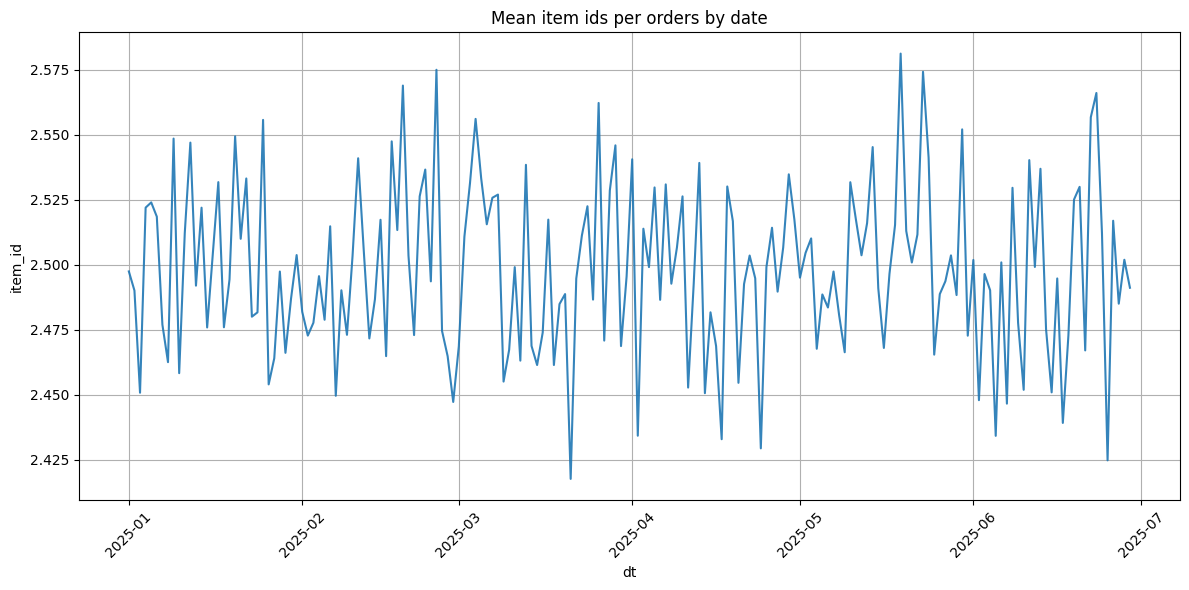

In [143]:
#check if it's stable 
mean_item_ids_per_order_per_date_df = df.groupby(['order_id', 'dt']).agg({'item_id': 'count'}).reset_index().groupby('dt').agg({'item_id': 'mean'}).reset_index()
pack.plot_ts(df = mean_item_ids_per_order_per_date_df, date_col = 'dt', is_groups = False, value_col = 'item_id', title = 'Mean item ids per orders by date')

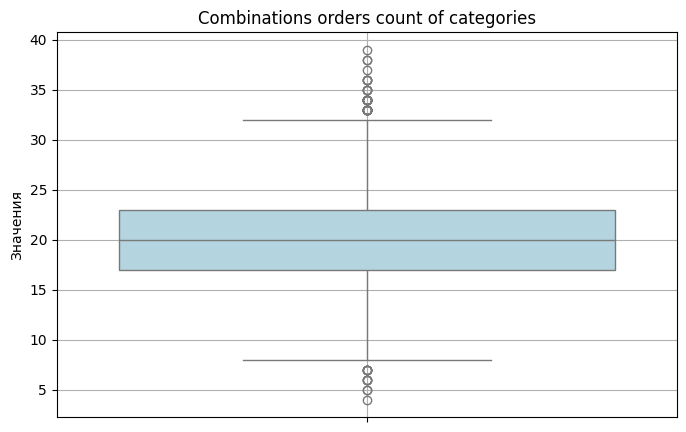

In [237]:
# Grouping the DataFrame by 'order_id', creating pairs of ('category_id', 'quantity') for each order
grouped = df.groupby('order_id')[['category_id', 'quantity']].apply(lambda x: list(zip(x['category_id'], x['quantity'])))

# Initialize dictionaries to store counts and total quantities of category pairs
pair_counts = {}
pair_quantities = {}

# Iterate through each order to count pairs of categories and their quantities
for items in grouped:
    # Extract categories and quantities from the tuple
    categories = [cat for cat, qty in items]  # List of category_ids
    quantities_list = [qty for cat, qty in items]  # List of corresponding quantities
    
    # Remove duplicate categories and proceed only if there are at least two unique categories in the order
    unique_categories = set(categories)
    if len(unique_categories) < 2:
        continue  # Skip orders with fewer than two categories

    # Generate all possible pairs of categories from the unique categories in the order
    for pair in itertools.combinations(sorted(unique_categories), 2):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1  # Count the number of times this category pair appears in an order

        # Calculate the total quantity of items for the current category pair in the order
        qty_sum = sum(qty for cat, qty in items if cat in pair)  # Sum the quantities for the items in the pair
        pair_quantities[pair] = pair_quantities.get(pair, 0) + qty_sum  # Sum the quantities of this pair across all orders

# Convert the pair_counts and pair_quantities dictionaries into a DataFrame
category_pair_df = pd.DataFrame([
    {
        'category_id_1': k[0],
        'category_id_2': k[1],
        'order_count': pair_counts[k],  # Number of orders containing this pair of categories
        'total_quantity': pair_quantities[k]  # Total quantity of items ordered for this category pair
    }
    for k in pair_counts
])

# Sort the DataFrame by the 'order_count' column in descending order to highlight the most frequent pairs
category_pair_df = category_pair_df.sort_values(by='order_count', ascending=False).reset_index(drop=True)

# Plot a box plot to visualize the distribution of the order counts for category pairs
pack.plot_box(category_pair_df['order_count'], title='Combinations orders count of categories')


In [238]:
category_pair_df

,category_id_1,category_id_2,order_count,total_quantity
0,14,98,39,191
1,77,85,38,196
2,109,110,38,190
3,3,104,37,194
4,107,139,36,168
...,...,...,...,...
11021,131,146,6,34
11022,24,94,6,28
11023,66,147,5,20
11024,7,92,5,21


In [239]:
# Grouping orders by order_id and aggregating item_ids as lists of items per order
orders_df = df.groupby('order_id').agg({'item_id': list}).reset_index()

# Creating a DataFrame that maps item_id to category_id, ensuring there are no duplicates
items_and_categories_df = df[['category_id', 'item_id']].drop_duplicates(subset=['item_id', 'category_id'])

def match_items_recommendation(item_ids, items_and_categories_df, category_pair_df, n_recommendations=3):
    """
    This function recommends items based on the content of orders and historical data.
    It first finds a category for each item, and then finds the most frequent item pairs
    from historical orders to generate recommendations.

    Arguments:
    item_ids (list): List of item_ids to generate recommendations for.
    items_and_categories_df (DataFrame): A DataFrame mapping item_id to category_id.
    category_pair_df (DataFrame): A DataFrame containing pairs of categories with order count and total quantity data.
    n_recommendations (int): The number of recommendations to generate for each item.

    Returns:
    result_df (DataFrame): A DataFrame containing the recommended items and their details.
    """

    result_rows = []  # List to store recommendation results
    all_item_ids = items_and_categories_df['item_id'].unique()  # List of all unique item_ids

    # Loop over each item_id in the input list of item_ids
    for item_id in item_ids:
        # Step 1: Find the category for the given item_id
        matched_row = items_and_categories_df[items_and_categories_df['item_id'] == item_id]
        
        if matched_row.empty:
            # If the item_id does not have a category, recommend random items
            random_recs = np.random.choice(all_item_ids, size=n_recommendations, replace=False)
            for rec_item_id in random_recs:
                result_rows.append({
                    'item_id': item_id,
                    'recommended_item_id': rec_item_id,
                    'recommended_category_id': None,
                    'source_type': 'random'
                })
            continue

        # Retrieve the category_id for the item
        cat_id = matched_row.iloc[0]['category_id']

        # Step 2: Find the top category pair based on total quantity (if equal, order_count)
        mask = (category_pair_df['category_id_1'] == cat_id) | (category_pair_df['category_id_2'] == cat_id)
        pairs = category_pair_df[mask].copy()
        
        if pairs.empty:
            # If no category pairs exist, recommend random items
            random_recs = np.random.choice(all_item_ids, size=n_recommendations, replace=False)
            for rec_item_id in random_recs:
                result_rows.append({
                    'item_id': item_id,
                    'recommended_item_id': rec_item_id,
                    'recommended_category_id': None,
                    'source_type': 'random'
                })
            continue

        # Sort the pairs by total_quantity and order_count in descending order
        pairs = pairs.sort_values(by=['total_quantity', 'order_count'], ascending=False)

        # Step 3: Select the top recommendation (based on total_quantity, if equal — by order_count)
        top_pairs = pairs.groupby(['category_id_1', 'category_id_2']).apply(lambda group: group.iloc[0]).reset_index(drop=True)

        # Handle ties: if multiple recommendations have the same values, select one randomly
        if len(top_pairs) > 1 and (top_pairs['total_quantity'].iloc[0] == top_pairs['total_quantity'].iloc[1] or 
                                   top_pairs['order_count'].iloc[0] == top_pairs['order_count'].iloc[1]):
            top_pair = top_pairs.sample(n=1)  # Random selection in case of tie
            source_type = 'pair_based: random'
        else:
            # Otherwise, select the top pair based on total_quantity or order_count
            top_pair = top_pairs.iloc[0]
            source_type = 'pair_based: top_quantity' if top_pair['total_quantity'] > top_pair['order_count'] else 'pair_based: top_order_count'

        # Determine the category of the second item in the top pair
        top_pair_cat = top_pair['category_id_2'] if top_pair['category_id_1'] == cat_id else top_pair['category_id_1']

        # Step 4: Find item_ids from the category of the top pair, selecting n_recommendations items
        recommended_items = items_and_categories_df[items_and_categories_df['category_id'] == top_pair_cat]
        recommended_item_ids = recommended_items['item_id'].value_counts().head(n_recommendations).index.tolist()

        # If fewer than n_recommendations were found, add random items to meet the count
        source_types = [source_type] * len(recommended_item_ids)
        if len(recommended_item_ids) < n_recommendations:
            missing = n_recommendations - len(recommended_item_ids)
            extra_randoms = np.random.choice(
                [i for i in all_item_ids if i not in recommended_item_ids],
                size=missing,
                replace=False
            )
            recommended_item_ids.extend(extra_randoms)
            source_types.extend(['random'] * missing)

        # Remove duplicate item_ids from the recommendations
        seen_items = set()
        for rec_item_id, source in zip(recommended_item_ids, source_types):
            if rec_item_id not in seen_items:
                result_rows.append({
                    'item_id': item_id,
                    'recommended_item_id': rec_item_id,
                    'recommended_category_id': top_pair_cat,
                    'source_type': source
                })
                seen_items.add(rec_item_id)

    # Step 5: Convert the results into a DataFrame and return it
    result_df = pd.DataFrame(result_rows)
    return result_df

In [244]:
#example
item_ids = [1070, 1554, 531]
match_items_recommendation(item_ids, items_and_categories_df, category_pair_df, n_recommendations=3)

C:\Users\Сергей\AppData\Local\Temp\ipykernel_17552\1884999529.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_pairs = pairs.groupby(['category_id_1', 'category_id_2']).apply(lambda group: group.iloc[0]).reset_index(drop=True)
C:\Users\Сергей\AppData\Local\Temp\ipykernel_17552\1884999529.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_pairs = pairs.groupby(['category_id_1', 'category_id_2']

,item_id,recommended_item_id,recommended_category_id,source_type
0,1070,1203,1,pair_based: top_quantity
1,1070,404,1,pair_based: top_quantity
2,1070,1501,1,pair_based: top_quantity
3,1554,1203,1,pair_based: top_quantity
4,1554,404,1,pair_based: top_quantity
5,1554,1501,1,pair_based: top_quantity
6,531,1203,1,pair_based: top_quantity
7,531,404,1,pair_based: top_quantity
8,531,1501,1,pair_based: top_quantity


In [227]:
item_ids = [1070, 1554, 531]  # Пример item_id
recommendations_df = match_items_recommendation(item_ids, items_and_categories_df, category_pair_df, n_recommendations=2)
recommendations_df

C:\Users\Сергей\AppData\Local\Temp\ipykernel_17552\2289814329.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_pairs = pairs.groupby(['category_id_1', 'category_id_2']).apply(lambda group: group.iloc[0]).reset_index(drop=True)
C:\Users\Сергей\AppData\Local\Temp\ipykernel_17552\2289814329.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_pairs = pairs.groupby(['category_id_1', 'category_id_2']

,item_id,recommended_item_id,recommended_category_id,source_type
0,1070,1203,1,pair_based: top_quantity
1,1070,404,1,pair_based: top_quantity
2,1554,1203,1,pair_based: top_quantity
3,1554,404,1,pair_based: top_quantity
4,531,1203,1,pair_based: top_quantity
5,531,404,1,pair_based: top_quantity
